### Imports
---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision.models.feature_extraction import create_feature_extractor
import torch.nn as nn
from typing import *

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

### Toy Dataset Building
---

In [ ]:
class BinaryHypercubeDataset(Dataset):
    def __init__(self, num_samples, N_dims=2, random_segment_ratios=False, spacing=2, noise_level=2):
        super(BinaryHypercubeDataset, self).__init__()

        self.__make_dataset__(num_samples, N_dims, random_segment_ratios, spacing, noise_level)

    def __flip_every_other_set__(self, array):
        # Ensure the array is a NumPy array
        array = np.array(array)

        # Reshape the array to separate pairs for easy manipulation
        pairs = array.reshape(-1, 2)

        # Flip every other pair
        pairs[1::2] = pairs[1::2, ::-1]

        # Reshape back to the original shape
        flipped_array = pairs.reshape(-1)
        return flipped_array

    def __make_dataset__(self, num_samples, N_dims, random_segment_ratios, spacing, noise_level):
        if random_segment_ratios:
            splits = np.random.dirichlet(np.ones(2**N_dims), size=1) * num_samples
            splits = list(splits)
        else:
            splits = [num_samples//(2**N_dims) for _ in range(2**N_dims)]

        splits = [0] + splits
        splits = np.cumsum(splits)
        corners_str = [bin(i)[2:].zfill(N_dims) for i in range(2**N_dims)]
        corners_list = np.array([[int(i) for i in c] for c in corners_str])
        corners_list *= spacing

        label_sets = [i%2 for i in range(2**N_dims)]
        label_sets = np.array(label_sets)
        label_sets = self.__flip_every_other_set__(label_sets)

        self.hf_dataset = np.zeros((num_samples, N_dims))
        self.lf_dataset = np.zeros((num_samples, N_dims))
        self.labels = np.zeros(num_samples)

        for s in range(1, len(splits)):
            # print(splits[s-1],splits[s])
            self.hf_dataset[splits[s-1]:splits[s]] = np.random.multivariate_normal(corners_list[s-1], np.zeros((N_dims,N_dims)), size=(splits[s]-splits[s-1]))
            # print(s-1)
            self.labels[splits[s-1]:splits[s]] = label_sets[s-1]

        self.lf_dataset = self.hf_dataset + np.random.standard_normal(size=(len(self.hf_dataset), N_dims)) * noise_level
        self.hf_dataset += np.random.standard_normal(size=(len(self.hf_dataset), N_dims)) * .4

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, idx:int):
        return self.lf_dataset[idx], self.hf_dataset[idx], self.labels[idx]

In [ ]:
ds = BinaryHypercubeDataset(4000, N_dims=2, noise_level=.8)

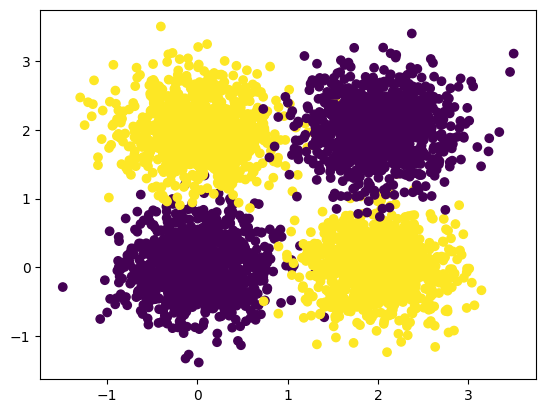

In [ ]:
plt.scatter(ds.hf_dataset[:,0], ds.hf_dataset[:,1], c=ds.labels)

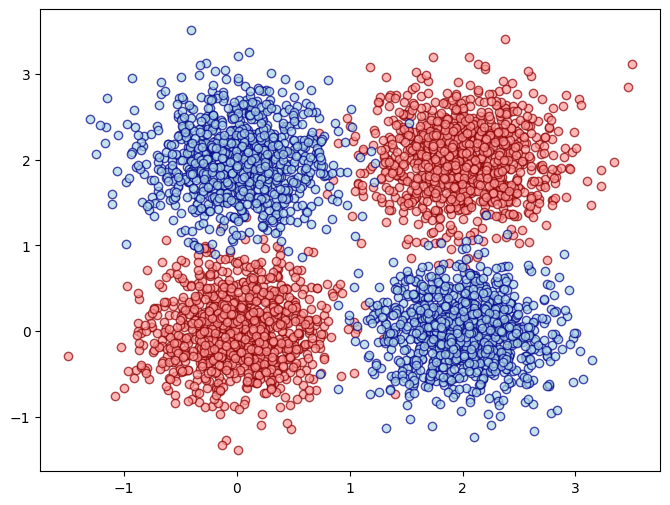

In [ ]:
colors = np.array(['#FF9999', '#ADD8E6'])
edge_colors = np.array(['#8B0000', '#00008B'])

plt.figure(figsize=(8, 6))
for label in np.unique(ds.labels):
    label = int(label)
    plt.scatter(
        ds.hf_dataset[ds.labels == label, 0],
        ds.hf_dataset[ds.labels == label, 1],
        c=colors[label],
        edgecolors=edge_colors[label],
        alpha=0.7,
        label=f'Label {label}'
    )


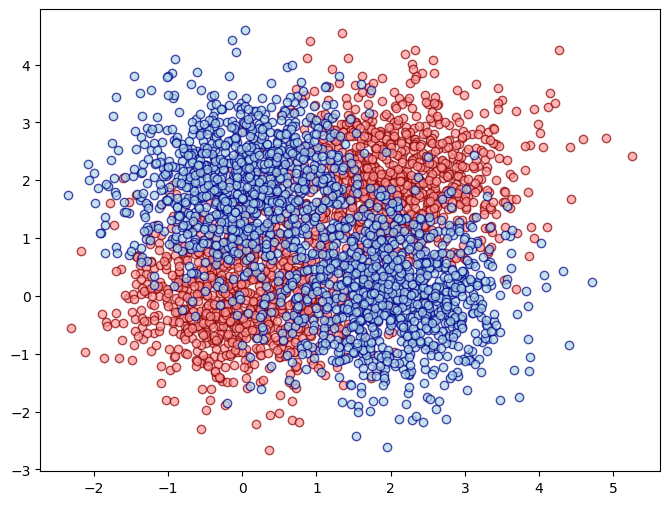

In [ ]:
colors = np.array(['#FF9999', '#ADD8E6'])
edge_colors = np.array(['#8B0000', '#00008B'])

plt.figure(figsize=(8, 6))
for label in np.unique(ds.labels):
    label = int(label)
    plt.scatter(
        ds.lf_dataset[ds.labels == label, 0],
        ds.lf_dataset[ds.labels == label, 1],
        c=colors[label],
        edgecolors=edge_colors[label],
        alpha=0.7,
        label=f'Label {label}'
    )

In [ ]:
def build_dataloaders(full_dataset, noise=1):
    # train_dataset = BinaryHypercubeDataset(1275, noise_level=noise)
    # test_dataset = BinaryHypercubeDataset(150, noise_level=noise)
    # val_dataset = BinaryHypercubeDataset(75, noise_level=noise)

    rand_idxs = np.random.choice(3, p=[.85, .1, .05], size=len(full_dataset))
    idxs = np.arange(len(full_dataset))

    train_dataset = Subset(full_dataset, idxs[rand_idxs==0])

    test_dataset = Subset(full_dataset, idxs[rand_idxs==1])
    val_dataset = Subset(full_dataset, idxs[rand_idxs==2])

    train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=512, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=512, shuffle=True)

    return train_loader, test_loader, val_loader

In [ ]:
class EarlyStopper:
    def __init__(self, patience=1, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.min_validation_loss = float('inf')

    def early_stop(self, validation_loss):
        if validation_loss < self.min_validation_loss:
            self.min_validation_loss = validation_loss
            self.counter = 0
        elif validation_loss > (self.min_validation_loss + self.min_delta):
            self.counter += 1
            if self.counter >= self.patience:
                return True
        return False

### Dataset for QE Model
---

In [ ]:
class QE_Dataset(Dataset):
    def __init__(self, lf_embeddings, lf_preds, hf_preds, labels):
        super(QE_Dataset, self).__init__()

        self.lf_embeddings = lf_embeddings
        self.lf_preds = lf_preds
        self.hf_preds = hf_preds
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx:int):
        return self.lf_embeddings[idx], self.lf_preds[idx], self.hf_preds[idx], self.labels[idx]

In [ ]:
def build_qe_dataloaders(lf_model, hf_model, train_loader, test_loader, val_loader):
    lf_body = create_feature_extractor(
        lf_model, {"7": "body"}
    ).to(device)

    lf_body.eval()
    lf_model.eval()
    hf_model.eval()

    train_len = len(train_loader.dataset)
    test_len = len(test_loader.dataset)
    val_len = len(val_loader.dataset)

    batch_size = train_loader.batch_size

    train_qe_labels = np.zeros(train_len)
    test_qe_labels = np.zeros(test_len)
    val_qe_labels = np.zeros(val_len)

    train_lf_embeddings = np.zeros((train_len, 32))
    test_lf_embeddings = np.zeros((test_len, 32))
    val_lf_embeddings = np.zeros((val_len, 32))

    train_hf_preds = np.zeros((train_len, 2))
    test_hf_preds = np.zeros((test_len, 2))
    val_hf_preds = np.zeros((val_len, 2))

    train_lf_preds = np.zeros((train_len, 2))
    test_lf_preds = np.zeros((test_len, 2))
    val_lf_preds = np.zeros((val_len, 2))


    print("Building Train Dataset...")
    for i, (lf_data, hf_data, target) in enumerate(train_loader):
        target = target.type(torch.LongTensor)
        lf_data, hf_data, target = lf_data.to(device, torch.float), hf_data.to(device, torch.float), target.to(device)

        lf_preds = lf_model(lf_data)
        hf_preds = hf_model(hf_data)
        lf_embeddings = lf_body(lf_data)["body"]

        train_qe_labels[
            (i*batch_size):(i*batch_size+len(target))
        ] = target.detach().cpu().numpy()

        train_lf_preds[
            (i*batch_size):(i*batch_size+len(target))
        ] = lf_preds.detach().cpu().numpy()

        train_hf_preds[
            (i*batch_size):(i*batch_size+len(target))
        ] = hf_preds.detach().cpu().numpy()

        train_lf_embeddings[
            (i*batch_size):(i*batch_size+len(target))
        ] = lf_embeddings.detach().cpu().numpy()

    train_dataset = QE_Dataset(train_lf_embeddings, train_lf_preds, train_hf_preds, train_qe_labels)

    print("Building Test Dataset...")
    for i, (lf_data, hf_data, target) in enumerate(test_loader):
        target = target.type(torch.LongTensor)
        lf_data, hf_data, target = lf_data.to(device, torch.float), hf_data.to(device, torch.float), target.to(device)

        lf_preds = lf_model(lf_data)
        hf_preds = hf_model(hf_data)
        lf_embeddings = lf_body(lf_data)["body"]

        test_qe_labels[
            (i*batch_size):(i*batch_size+len(target))
        ] = target.detach().cpu().numpy()

        test_lf_preds[
            (i*batch_size):(i*batch_size+len(target))
        ] = lf_preds.detach().cpu().numpy()

        test_hf_preds[
            (i*batch_size):(i*batch_size+len(target))
        ] = hf_preds.detach().cpu().numpy()

        test_lf_embeddings[
            (i*batch_size):(i*batch_size+len(target))
        ] = lf_embeddings.detach().cpu().numpy()

    test_dataset = QE_Dataset(test_lf_embeddings, test_lf_preds, test_hf_preds, test_qe_labels)

    print("Building Validation Dataset...")
    for i, (lf_data, hf_data, target) in enumerate(val_loader):
        target = target.type(torch.LongTensor)
        lf_data, hf_data, target = lf_data.to(device, torch.float), hf_data.to(device, torch.float), target.to(device)

        lf_preds = lf_model(lf_data)
        hf_preds = hf_model(hf_data)
        lf_embeddings = lf_body(lf_data)["body"]

        val_qe_labels[
            (i*batch_size):(i*batch_size+len(target))
        ] = target.detach().cpu().numpy()

        val_lf_preds[
            (i*batch_size):(i*batch_size+len(target))
        ] = lf_preds.detach().cpu().numpy()

        val_hf_preds[
            (i*batch_size):(i*batch_size+len(target))
        ] = hf_preds.detach().cpu().numpy()

        val_lf_embeddings[
            (i*batch_size):(i*batch_size+len(target))
        ] = lf_embeddings.detach().cpu().numpy()

    val_dataset = QE_Dataset(val_lf_embeddings, val_lf_preds, val_hf_preds, val_qe_labels)

    train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=512)
    val_loader = DataLoader(val_dataset, batch_size=512)

    return train_loader, test_loader, val_loader


### Training & Loss Functions
---

In [ ]:
def one_run(model, dataloader, criterion, fidelity, optimizer=None, scheduler=None):
    """
    Perform one run through the DataLoader.

    Args:
    - model (torch.nn.Module): The neural network model.
    - dataloader (DataLoader): The DataLoader for iterating over the dataset.
    - criterion (callable): The loss function.
    - optimizer (torch.optim.Optimizer, optional): The optimizer for updating model weights.

    Returns:
    - float: Average loss over the run.
    - int: Correct predictions for calculating accuracy if needed.
    """
    if fidelity not in ["lf", "hf", "gate"]:
        return

    model.train(mode=bool(optimizer))
    device = next(model.parameters()).device
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    total_high = 0
    if fidelity == "lf":
        for data, _, target in dataloader:
            target = target.type(torch.LongTensor)
            data, target = data.to(device, torch.float), target.to(device)
            output = model(data)
            loss = criterion(output, target)
            if optimizer:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * data.size(0)
            predicted = torch.argmax(output, dim=1)
            total_correct += (predicted == target).sum().item()
            total_samples += data.size(0)
        if scheduler:
            scheduler.step()

    elif fidelity == "hf":
        for _, data, target in dataloader:
            target = target.type(torch.LongTensor)
            data, target = data.to(device, torch.float), target.to(device)
            output = model(data)
            loss = criterion(output, target)
            if optimizer:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * data.size(0)
            predicted = torch.argmax(output, dim=1)
            total_correct += (predicted == target).sum().item()
            total_samples += data.size(0)
        if scheduler:
            scheduler.step()

    elif fidelity == "gate":
        for lf_embeddings, lf_preds, hf_preds, target in dataloader:
            lf_embeddings = lf_embeddings.to(device, torch.float)
            lf_preds = lf_preds.to(device, torch.float)
            hf_preds = hf_preds.to(device, torch.float)

            target = target.type(torch.LongTensor)
            target = target.to(device)

            outputs = model(lf_embeddings)
            loss = criterion(outputs, hf_preds, lf_preds, target)
            if optimizer:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            choices = torch.argmax(outputs, dim=1)
            lf_acc = torch.argmax(lf_preds, dim=1) == target
            hf_acc = torch.argmax(hf_preds, dim=1) == target

            total_loss += loss.item() * lf_preds.size(0)
            total_correct += torch.sum(hf_acc[choices==1]) + torch.sum(lf_acc[choices==0]).item()
            total_samples += lf_preds.size(0)
            total_high += torch.sum(choices).item()
        if scheduler:
            scheduler.step()

    average_loss = total_loss / total_samples
    accuracy = total_correct / total_samples

    if fidelity=="gate":
        high_count = total_high / total_samples
        return average_loss, accuracy.item(), high_count

    return average_loss, accuracy

In [ ]:
class MetaLoss(nn.Module):
    def __init__(self, ch=1, cw=10):
        '''
        Loss function for the FE model
        Parameters:
            ch - cost of using high fidelity
            cw - cost of being wrong
        '''
        super().__init__()
        self.ch = ch
        self.cw = cw
        self.r = ch/cw # make r value
        self.criterion = nn.CrossEntropyLoss(reduction="none") # use crossentropyloss
        # self.criterion = nn.BCELoss(reduction="sum")

        self.tot_cost = 0
        self.E_ch = 0
        self.E_cw = 0
        self.weights = 0

        # 0-TN, 1-FN, 2-FP, 3-TP
        self.metrics = np.array([
            [0, 1],
            [2, 3]
        ])

    def forward(self, choices, hq_preds, lq_preds, act_labels):
        '''
        choices - the selection of the FE model
        hq_preds - the predictions from the hf model
        lq_preds -
        '''
        with torch.no_grad():
            hq_preds = torch.argmax(hq_preds, dim=1)
            lq_preds = torch.argmax(lq_preds, dim=1)
            act_labels = act_labels
            lq_inacc = lq_preds != act_labels
            hq_acc = hq_preds == act_labels
            gt = torch.logical_and(lq_inacc, hq_acc).type(torch.int64)
            qh = torch.argmax(choices, dim=1)

        q0_leq = torch.logical_and(qh==0, lq_inacc==0).type(torch.int64) * 0 # choose lq and lq correct
        q0_lneq = torch.logical_and(qh==0, lq_inacc==1).type(torch.int64) * self.cw # choose lq and lq incorrect
        q1_heq = torch.logical_and(qh==1, hq_acc==1).type(torch.int64) * self.ch # choose hq and hq correct
        q1_hneq = torch.logical_and(qh==1, hq_acc==0).type(torch.int64) * (self.cw + self.ch) # choose hq and hq incorrect

        self.weights = q0_leq + q0_lneq + q1_heq + q1_hneq

        loss_values = self.criterion(choices, gt)

        self.tot_cost = (loss_values @ self.weights) / len(act_labels)

        return self.tot_cost

    def get_info(self):
        # return self.tot_cost, self.E_ch, self.E_cw
        return self.tot_cost, self.weights

In [ ]:
class MetaLoss(nn.Module):
    def __init__(self, ch=1, cw=10):
        '''
        Loss function for the FE model
        Parameters:
            ch - cost of using high fidelity
            cw - cost of being wrong
        '''
        super().__init__()
        self.ch = ch
        self.cw = cw
        self.r = ch/cw # make r value
        self.criterion = nn.CrossEntropyLoss(reduction="none") # use crossentropyloss
        # self.criterion = nn.BCELoss(reduction="sum")

        self.tot_cost = 0
        self.E_ch = 0
        self.E_cw = 0
        self.weights = 0

        # 0-TN, 1-FN, 2-FP, 3-TP
        self.metrics = np.array([
            [0, 1],
            [2, 3]
        ])

    def forward(self, choices, hq_preds, lq_preds, act_labels):
        '''
        choices - the selection of the FE model
        hq_preds - the predictions from the hf model
        lq_preds -
        '''
        with torch.no_grad():
            hq_preds = torch.argmax(hq_preds, dim=1)
            lq_preds = torch.argmax(lq_preds, dim=1)
            act_labels = act_labels
            lq_inacc = lq_preds != act_labels
            hq_acc = hq_preds == act_labels
            gt = torch.logical_and(lq_inacc, hq_acc).type(torch.int64)
            qh = torch.argmax(choices, dim=1)

        q0_leq = torch.logical_and(qh==0, lq_inacc==0).type(torch.int64) * 0 # choose lq and lq correct
        q0_lneq = torch.logical_and(qh==0, lq_inacc==1).type(torch.int64) * self.cw # choose lq and lq incorrect
        q1_heq = torch.logical_and(qh==1, hq_acc==1).type(torch.int64) * self.ch # choose hq and hq correct
        q1_hneq = torch.logical_and(qh==1, hq_acc==0).type(torch.int64) * (self.cw + self.ch) # choose hq and hq incorrect

        self.weights = q0_leq + q0_lneq + q1_heq + q1_hneq

        loss_values = self.criterion(choices, gt)

        self.tot_cost = (loss_values @ self.weights) / len(act_labels)

        return self.tot_cost

    def get_info(self):
        # return self.tot_cost, self.E_ch, self.E_cw
        return self.tot_cost, self.weights

In [ ]:
class MetaLossFunction(nn.Module):
    def __init__(self, ch: List[float], cw: float, loss_fun: str="CE"):
        '''
        Loss function for the FE model
        Parameters:
            ch - cost of using high fidelity
            cw - cost of being wrong
            loss_fun - the choice of loss function used to determine wrong predictions
        '''
        super().__init__()
        self.ch = ch
        self.ch.insert(0, 0) # first element is zero because no cost for LF sample usage

        self.cw = cw

        match loss_fun:
            case "CE":
                self.loss_fun = nn.CrossEntropyLoss(reduction="none")
            case "binary":
                self.loss_fun = nn.L1Loss(reduction="none")
            case default:
                raise ValueError("Invalid loss function")

    def forward(self, y_true: torch.tensor, y_preds: torch.tensor, choices: torch.tensor):
        batch_size = len(y_true)
        model_losses = []

        with torch.no_grad():
            for pred in y_preds:
                loss = self.loss_fun(y_preds, y_true)
                model_losses.append(loss)

        model_losses_tensor = torch.stack(model_losses)

        cw_matrix = self.cw * torch.ones_like(model_losses_tensor)
        ch_matrix = self.ch.view(-1, len(self.ch))
        ch_matrix = ch_matrix.repeat(batch_size, 1).T

        model_loss_weights = model_losses_tensor * (cw_matrix + ch_matrix)

        meta_loss = choices.T * model_loss_weights
        return meta_loss

In [ ]:
def build_qe_model(num_classes: int=2):
    qe_model = nn.Sequential(
        nn.Linear(32, 64),
        nn.ReLU(),
        nn.Linear(64, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, num_classes)
    )

    return qe_model

### Model Training
---

In [ ]:
R_VALS = np.linspace(0, 1, 30)
NUM_RERUNS = 100
NUM_FIDELITY_EPOCHS = 50
NUM_QE_EPOCHS = 200

In [ ]:
qe_train_acc = np.zeros((NUM_RERUNS, len(R_VALS)))
qe_train_bud = np.zeros((NUM_RERUNS, len(R_VALS)))

qe_test_acc = np.zeros((NUM_RERUNS, len(R_VALS)))
qe_test_bud = np.zeros((NUM_RERUNS, len(R_VALS)))

qe_val_acc = np.zeros((NUM_RERUNS, len(R_VALS)))
qe_val_bud = np.zeros((NUM_RERUNS, len(R_VALS)))

full_dataset = BinaryHypercubeDataset(4000, noise_level=1.3)

for run_num in range(NUM_RERUNS):
    lf_model = torch.nn.Sequential(
        torch.nn.Linear(2, 64),
        torch.nn.ReLU(),
        torch.nn.Linear(64, 128),
        torch.nn.ReLU(),
        torch.nn.Linear(128, 64),
        torch.nn.ReLU(),
        torch.nn.Linear(64, 32),
        torch.nn.ReLU(),
        torch.nn.Linear(32, 2)
    ).to(device)


    lf_optimizer = torch.optim.Adam(lf_model.parameters(), lr=3e-3, weight_decay=1e-5)
    criterion = torch.nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.ExponentialLR(lf_optimizer, gamma=0.99)
    early_stopper = EarlyStopper(patience=5)

    train_loader, test_loader, val_loader = build_dataloaders(full_dataset)


    for epoch in range(NUM_FIDELITY_EPOCHS):
        train_loss, train_acc = one_run(lf_model, train_loader, criterion, fidelity="lf", optimizer=lf_optimizer, scheduler=scheduler)
        test_loss, test_acc = one_run(lf_model, test_loader, criterion, fidelity="lf", optimizer=lf_optimizer, scheduler=scheduler)
        val_loss, val_acc = one_run(lf_model, val_loader, criterion, fidelity="lf", optimizer=lf_optimizer, scheduler=scheduler)

        print(train_acc, val_acc)
        if early_stopper.early_stop(val_loss):
            break
        # scheduler.step(

    print("\n\n\n")

    hf_model = torch.nn.Sequential(
        torch.nn.Linear(2, 64),
        torch.nn.ReLU(),
        torch.nn.Linear(64, 128),
        torch.nn.ReLU(),
        torch.nn.Linear(128, 64),
        torch.nn.ReLU(),
        torch.nn.Linear(64, 32),
        torch.nn.ReLU(),
        torch.nn.Linear(32, 2)
    ).to(device)

    hf_optimizer = torch.optim.Adam(hf_model.parameters(), lr=3e-3, weight_decay=1e-5)
    criterion = torch.nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.ExponentialLR(hf_optimizer, gamma=0.99)
    early_stopper = EarlyStopper(patience=5)

    for epoch in range(NUM_FIDELITY_EPOCHS):
        train_loss, train_acc = one_run(hf_model, train_loader, criterion, fidelity="hf", optimizer=hf_optimizer, scheduler=scheduler)
        test_loss, test_acc = one_run(hf_model, test_loader, criterion, fidelity="hf", optimizer=hf_optimizer, scheduler=scheduler)
        val_loss, val_acc = one_run(hf_model, val_loader, criterion, fidelity="hf", optimizer=hf_optimizer, scheduler=scheduler)

        print(train_acc, val_acc)
        if early_stopper.early_stop(val_loss):
            break

    qe_train_loader, qe_test_loader, qe_val_loader = build_qe_dataloaders(lf_model, hf_model, train_loader, test_loader, val_loader)

    for r, r_val in enumerate(R_VALS):
        print("Running r-value:", r_val)
        qe_model = build_qe_model()

        qe_model = qe_model.to(device)
        optimizer = torch.optim.Adam(qe_model.parameters(), lr=3e-4)
        scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=.985)
        loss_fun = MetaLoss(ch=r_val, cw=1)

        early_stopper = EarlyStopper(patience=8)

        for epoch in range(NUM_QE_EPOCHS):
            train_loss, train_acc, train_use = one_run(qe_model, qe_train_loader, loss_fun, fidelity="gate", optimizer=optimizer, scheduler=scheduler)
            test_loss, test_acc, test_use = one_run(qe_model, qe_test_loader, loss_fun, fidelity="gate")
            val_loss, val_acc, val_use = one_run(qe_model, qe_val_loader, loss_fun, fidelity="gate")

            # print(train_loss, train_acc, train_use)
            # print(val_loss, val_acc, val_use)
            qe_train_acc[run_num, r] = train_acc
            qe_train_bud[run_num, r] = train_use

            qe_test_acc[run_num, r] = test_acc
            qe_test_bud[run_num, r] = test_use

            qe_val_acc[run_num, r] = val_acc
            qe_val_bud[run_num, r] = val_use

            if early_stopper.early_stop(val_loss):
                break

Streaming output truncated to the last 5000 lines.
Running r-value: 0.1724137931034483
Running r-value: 0.20689655172413793
Running r-value: 0.24137931034482757
Running r-value: 0.27586206896551724
Running r-value: 0.3103448275862069
Running r-value: 0.3448275862068966
Running r-value: 0.3793103448275862
Running r-value: 0.41379310344827586
Running r-value: 0.4482758620689655
Running r-value: 0.48275862068965514
Running r-value: 0.5172413793103449
Running r-value: 0.5517241379310345
Running r-value: 0.5862068965517241
Running r-value: 0.6206896551724138
Running r-value: 0.6551724137931034
Running r-value: 0.6896551724137931
Running r-value: 0.7241379310344828
Running r-value: 0.7586206896551724
Running r-value: 0.7931034482758621
Running r-value: 0.8275862068965517
Running r-value: 0.8620689655172413
Running r-value: 0.896551724137931
Running r-value: 0.9310344827586207
Running r-value: 0.9655172413793103
Running r-value: 1.0
0.5787481804949054 0.643979057591623
0.6564774381368268 0.66

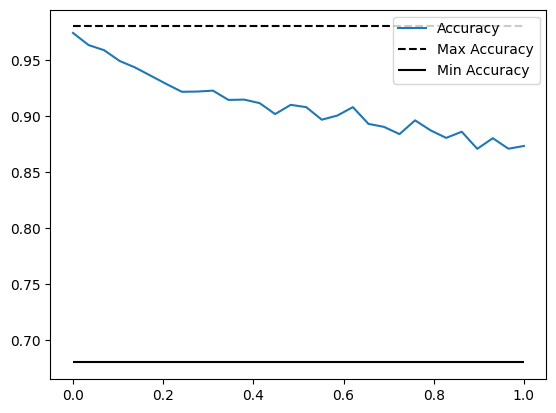

In [ ]:
plt.plot(R_VALS, np.mean(qe_val_acc, axis=0), label='val_acc')
plt.hlines(.98, 0, R_VALS[-1], "k", "--")
plt.hlines(.68, 0, R_VALS[-1], "k")

plt.legend(["Accuracy", "Max Accuracy", "Min Accuracy"])

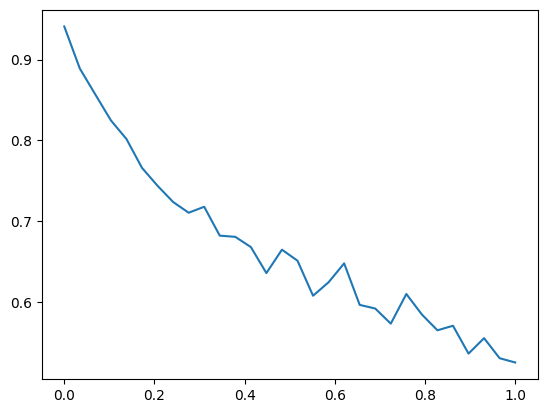

In [ ]:
plt.plot(R_VALS, np.mean(qe_val_bud, axis=0), label='val_bud')

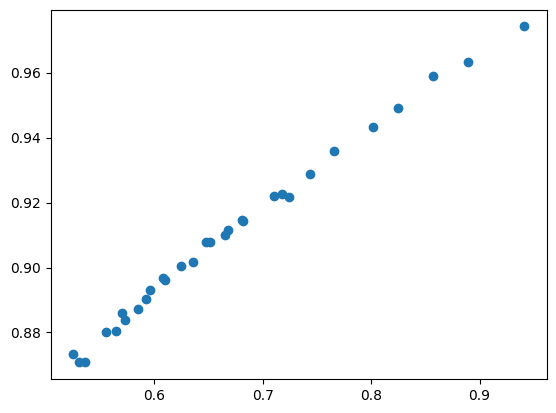

In [ ]:
plt.scatter(np.mean(qe_val_bud, axis=0), np.mean(qe_val_acc, axis=0), label='val_bud', )

In [ ]:
np.savez("/content/drive/MyDrive/toy_example_info.npz", rvals=R_VALS, val_acc=qe_val_acc, val_bud=qe_val_bud)

In [ ]:
from google.colab import runtime
runtime.unassign()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
a = np.load("./sample_data/trial_full_reruns3.npz")

In [ ]:
a.files

['r_vals',
 'train_acc',
 'test_acc',
 'val_acc',
 'train_use',
 'test_use',
 'val_use']

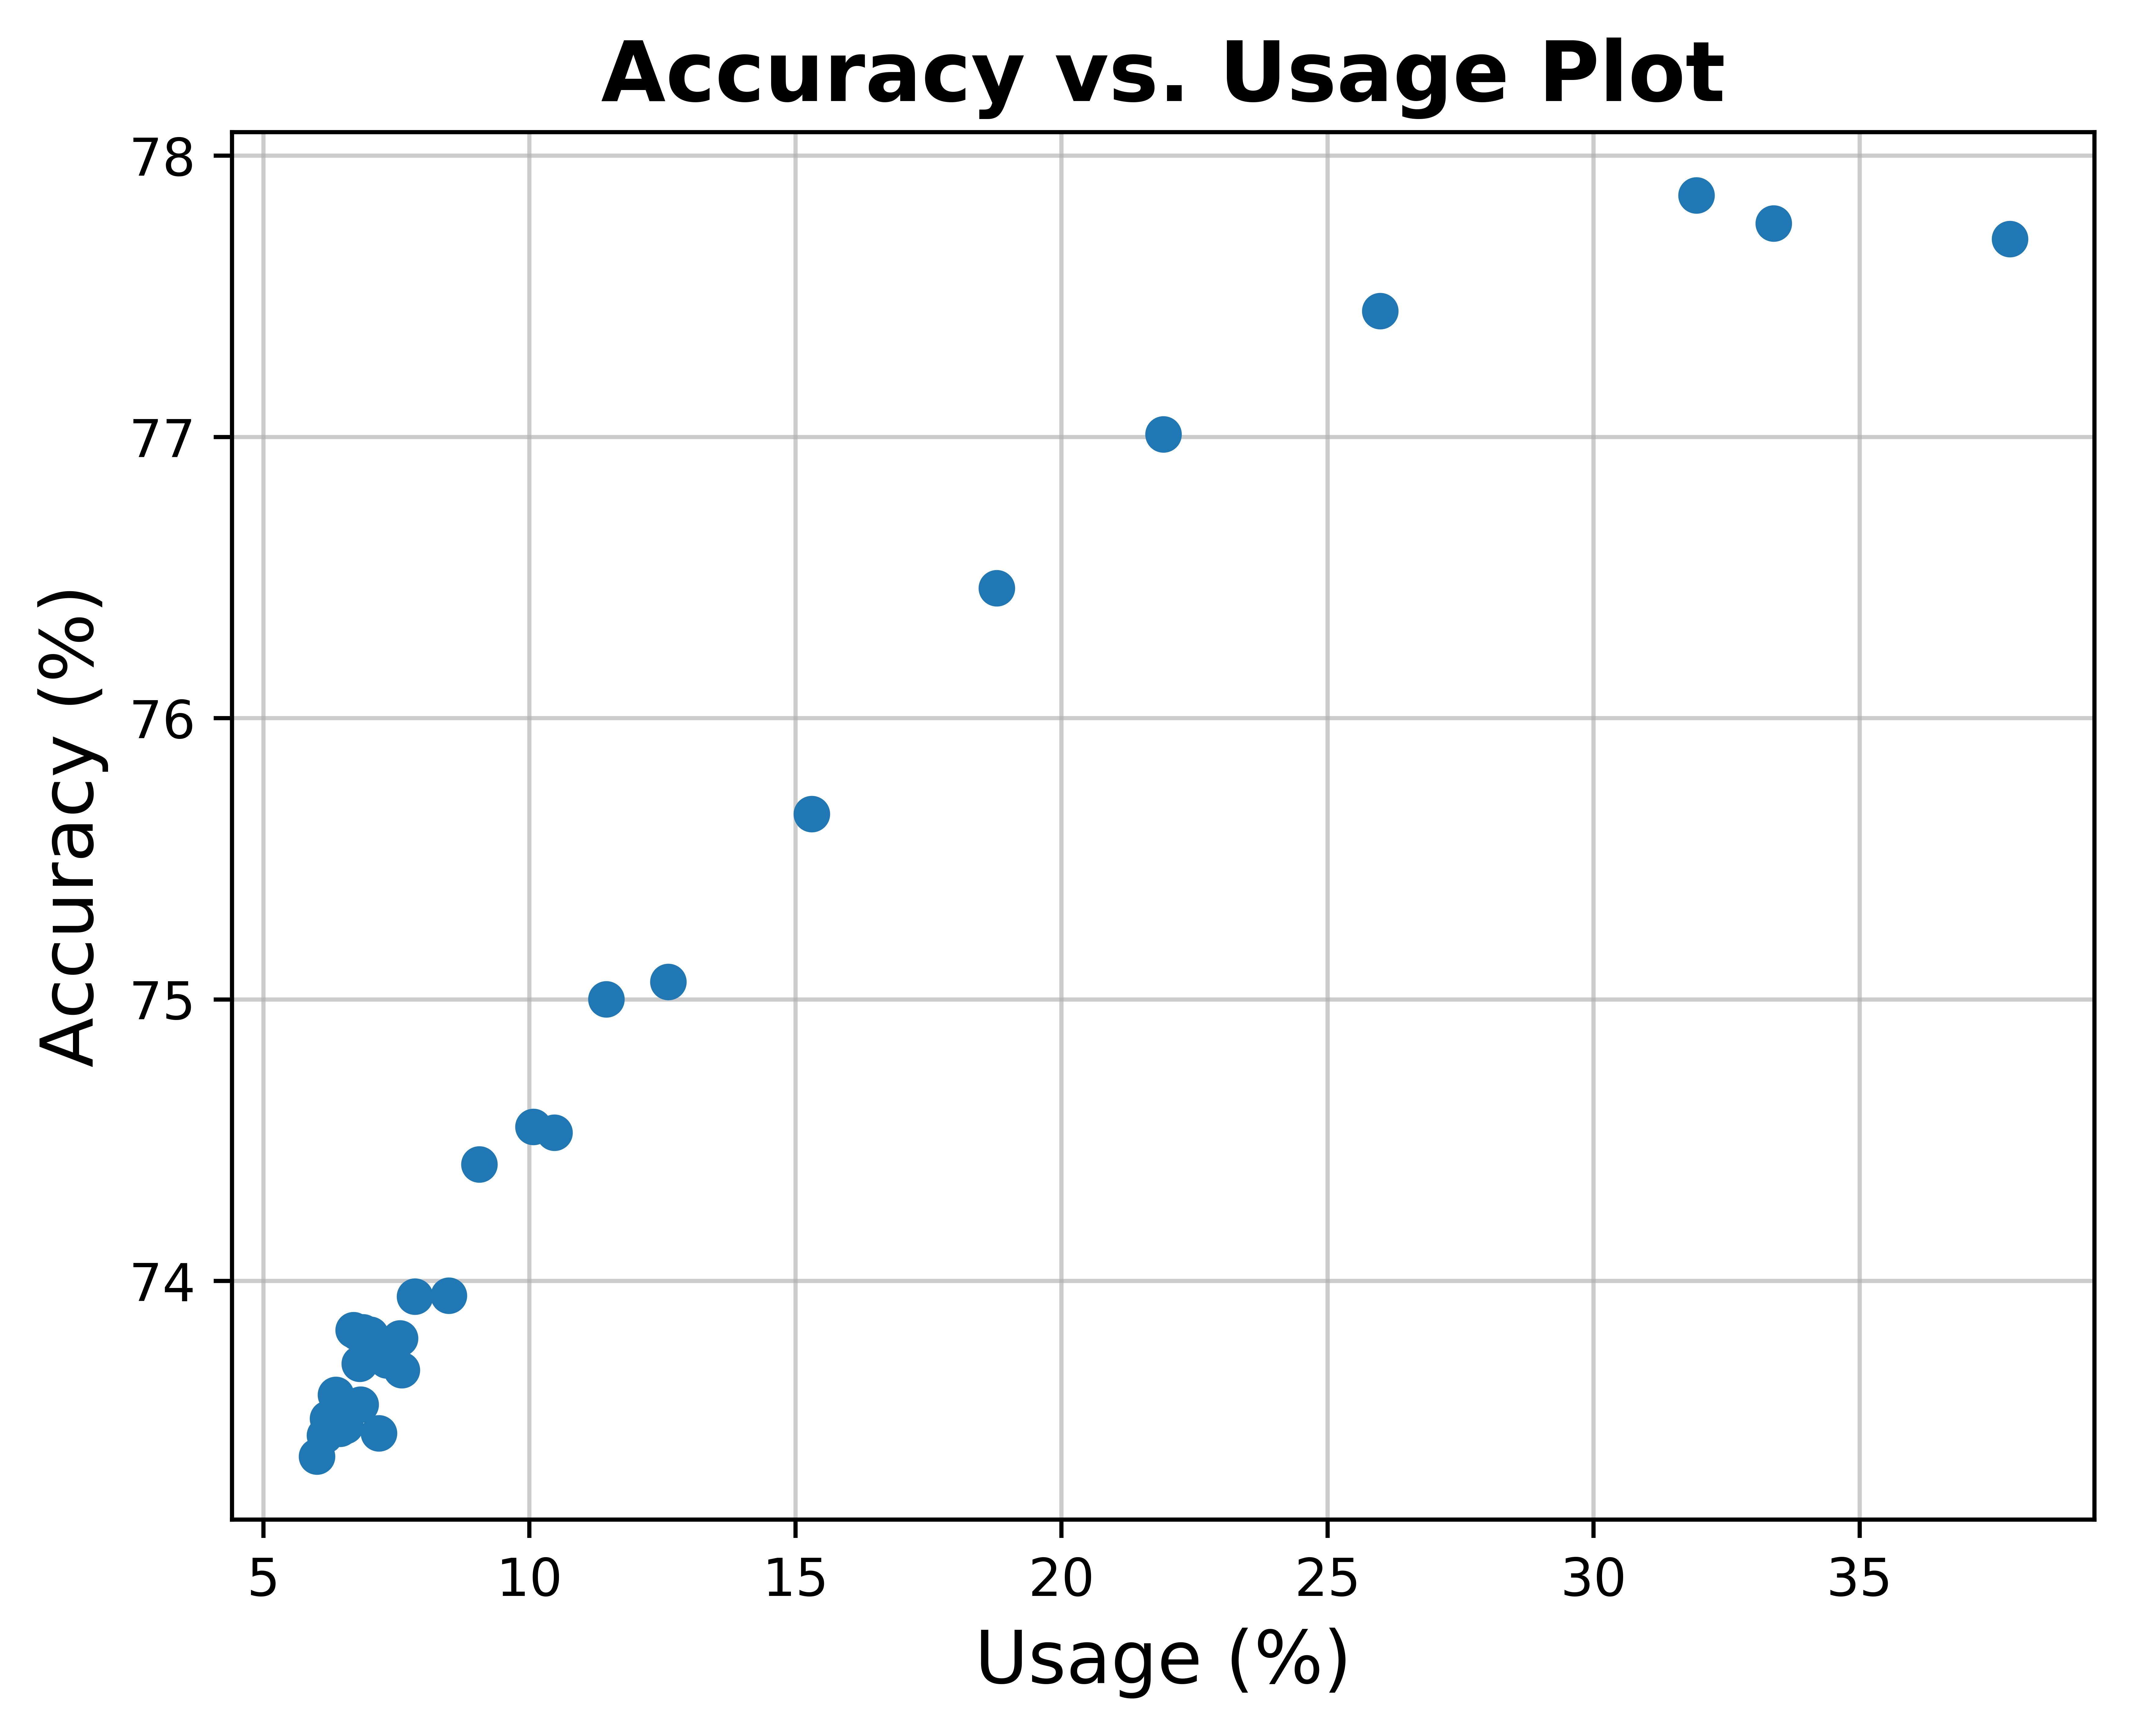

In [ ]:
plt.scatter(np.mean(a["test_use"]*100, axis=0), np.mean(a["test_acc"]*100, axis=0), label='test_bud', zorder=2)
plt.xlabel("Usage (%)", fontsize=14)
plt.ylabel("Accuracy (%)", fontsize=14)
plt.title("Accuracy vs. Usage Plot", fontweight="bold", fontsize=16)
plt.grid(alpha=.65, zorder=1)
plt.gcf().set_dpi(1230)

In [ ]:
a = np.load("./sample_data/toy_example_info.npz")

Text(0, 0.5, 'Accuracy (%)')

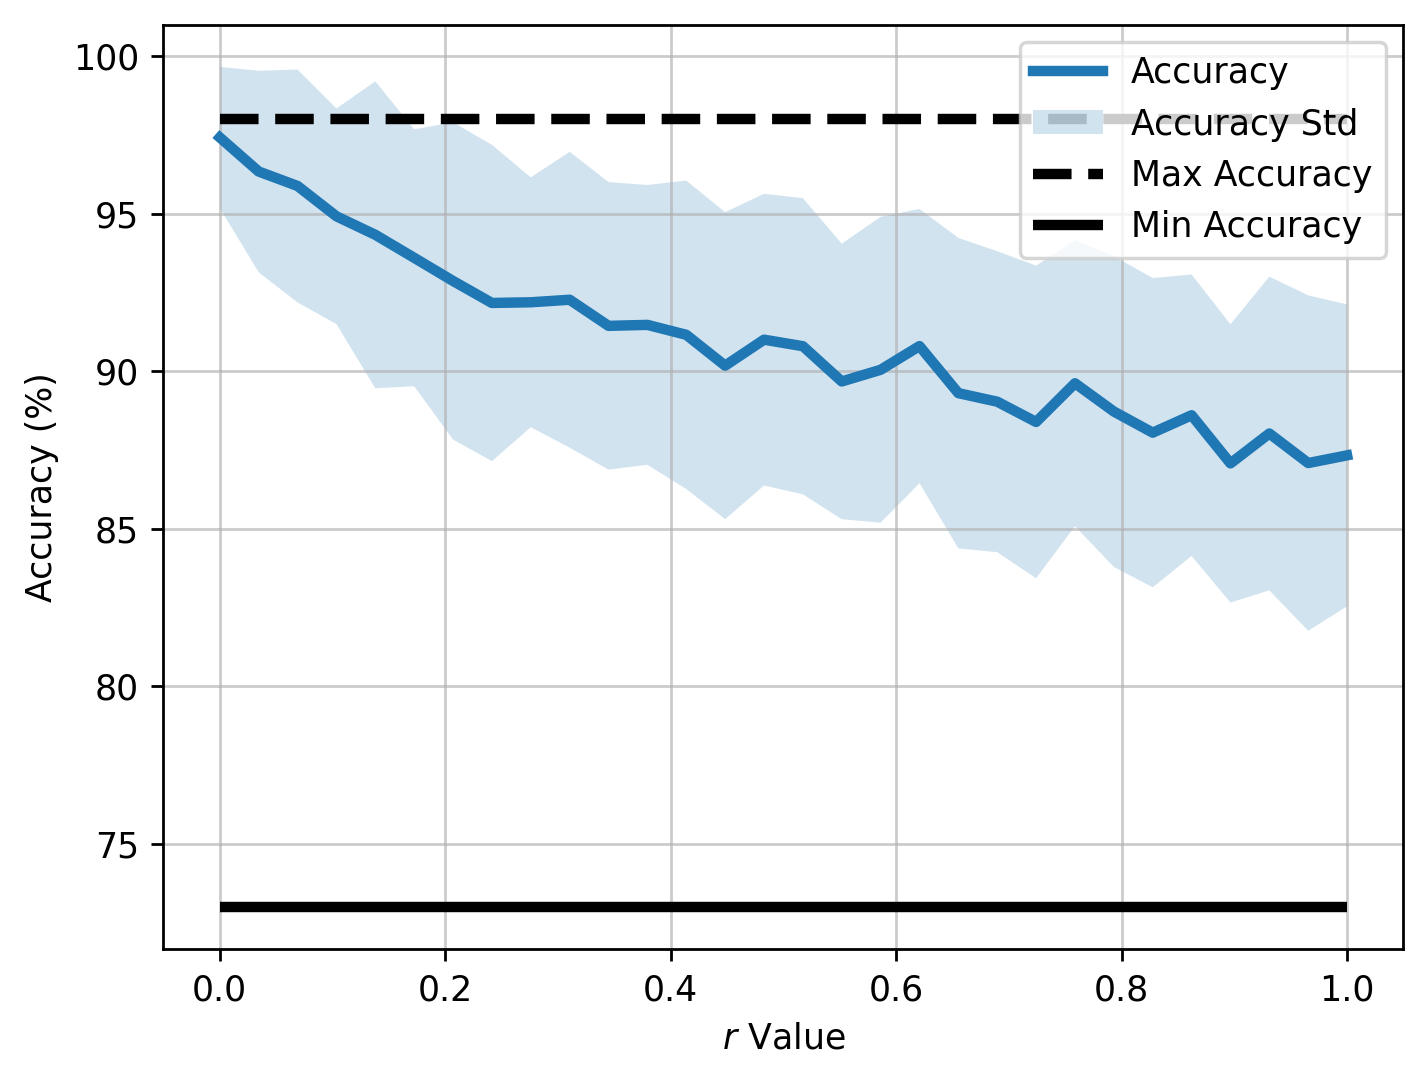

In [ ]:
plt.plot(a["rvals"], np.mean(a["val_acc"]*100, axis=0), label='val_acc', linewidth=3)
plt.fill_between(a["rvals"], np.mean(a["val_acc"]*100, axis=0)-np.std(a["val_acc"]*100, axis=0),
                 np.mean(a["val_acc"]*100, axis=0)+np.std(a["val_acc"]*100, axis=0), alpha=0.2)
plt.hlines(98, 0, a["rvals"][-1], "k", "--", linewidth=3)
plt.hlines(73, 0, a["rvals"][-1], "k", linewidth=3)

plt.legend(["Accuracy", "Accuracy Std", "Max Accuracy", "Min Accuracy"])
plt.grid(alpha=.65, zorder=1)
plt.gcf().set_dpi(250)

plt.xlabel("$r$ Value")
plt.ylabel("Accuracy (%)")

In [ ]:
np.max(a["val_bud"]*100)

100.0

Text(0, 0.5, 'Usage (%)')

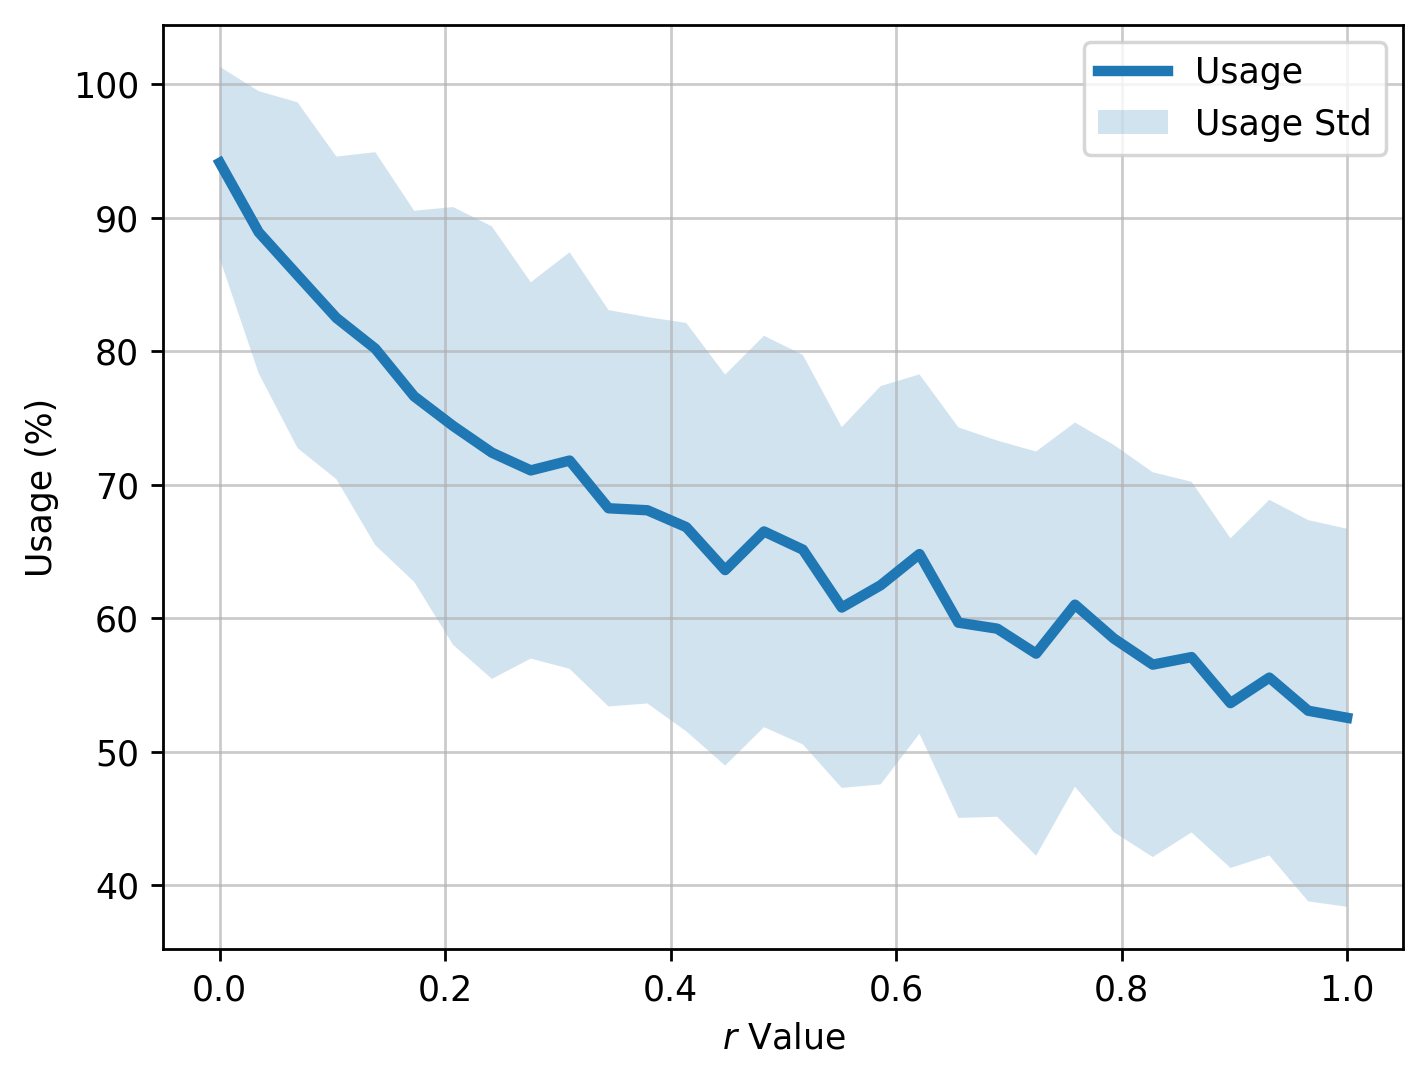

In [ ]:
plt.plot(a["rvals"], np.mean(a["val_bud"]*100, axis=0), label='val_bud', linewidth=3)
plt.fill_between(a["rvals"], np.mean(a["val_bud"]*100, axis=0)-np.std(a["val_bud"]*100, axis=0),
                 np.mean(a["val_bud"]*100, axis=0)+np.std(a["val_bud"]*100, axis=0), alpha=0.2)

plt.legend(["Usage", "Usage Std"])
plt.grid(alpha=.65, zorder=1)
plt.gcf().set_dpi(250)

plt.xlabel("$r$ Value")
plt.ylabel("Usage (%)")

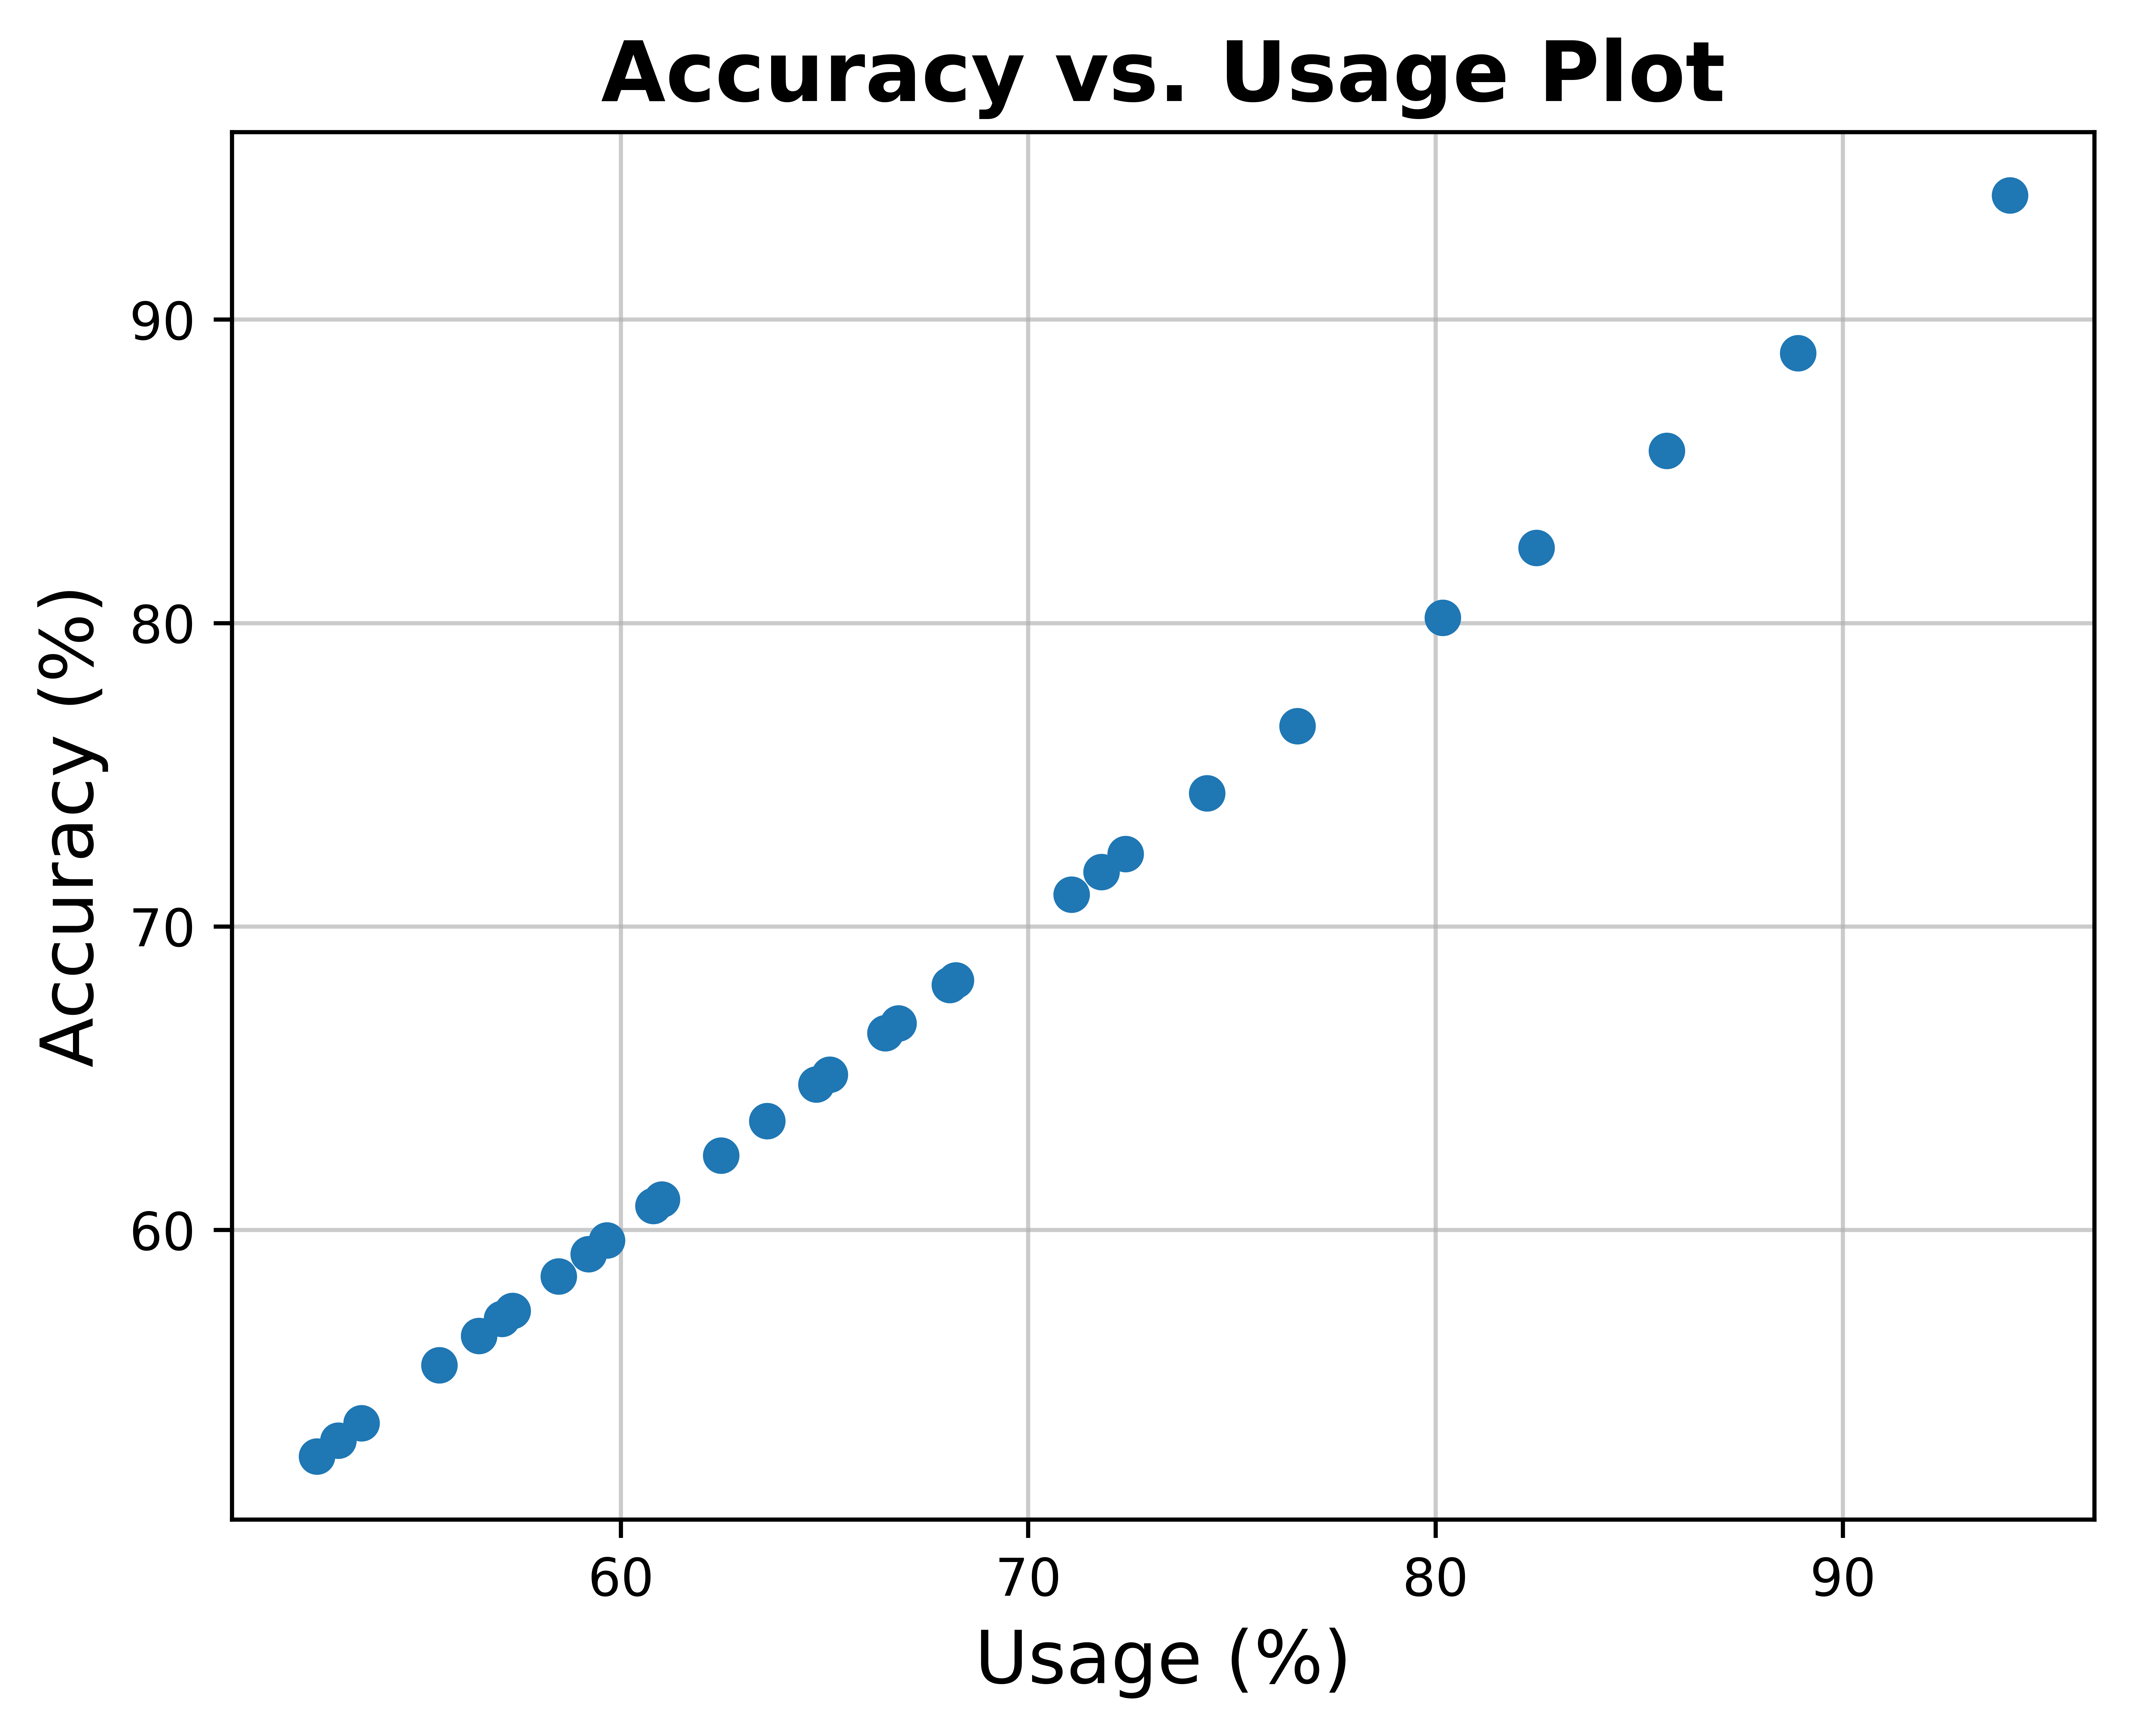

In [ ]:
plt.scatter(np.mean(a["val_bud"]*100, axis=0), np.mean(a["val_bud"]*100, axis=0), label='val_bud', zorder=2)
plt.xlabel("Usage (%)", fontsize=14)
plt.ylabel("Accuracy (%)", fontsize=14)
plt.title("Accuracy vs. Usage Plot", fontweight="bold", fontsize=16)
plt.grid(alpha=.65, zorder=1)
plt.gcf().set_dpi(1230)